In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/heart_disease.csv")

# Show the first 5 rows
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [7]:
import sqlite3

In [8]:
connection = sqlite3.connect("healthcare_validation.db")

print("Database created successfully!")

Database created successfully!


In [9]:
df.to_sql(
    "healthcare_data",
    connection,
    if_exists="replace",
    index=False
)

print("Healthcare dataset loaded into SQL successfully!")

Healthcare dataset loaded into SQL successfully!


In [10]:
query = """
SELECT *
FROM healthcare_data
LIMIT 5;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [11]:
query = """
SELECT COUNT(*) AS total_records
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,total_records
0,10000


In [12]:
query = """
SELECT
    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS Missing_Age,
    SUM(CASE WHEN Gender IS NULL THEN 1 ELSE 0 END) AS Missing_Gender,
    SUM(CASE WHEN BMI IS NULL THEN 1 ELSE 0 END) AS Missing_BMI,
    SUM(CASE WHEN [Blood Pressure] IS NULL THEN 1 ELSE 0 END) AS Missing_Blood_Pressure,
    SUM(CASE WHEN [Cholesterol Level] IS NULL THEN 1 ELSE 0 END) AS Missing_Cholesterol,
    SUM(CASE WHEN [Heart Disease Status] IS NULL THEN 1 ELSE 0 END) AS Missing_Heart_Disease_Status
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Missing_Age,Missing_Gender,Missing_BMI,Missing_Blood_Pressure,Missing_Cholesterol,Missing_Heart_Disease_Status
0,29,19,22,19,30,0


In [13]:
query = """
SELECT
    COUNT(*) AS Total_Records,

    ROUND(
        100.0 * COUNT(Age) / COUNT(*),
        2
    ) AS Age_Completeness_Percentage,

    ROUND(
        100.0 * COUNT(Gender) / COUNT(*),
        2
    ) AS Gender_Completeness_Percentage,

    ROUND(
        100.0 * COUNT(BMI) / COUNT(*),
        2
    ) AS BMI_Completeness_Percentage,

    ROUND(
        100.0 * COUNT([Blood Pressure]) / COUNT(*),
        2
    ) AS Blood_Pressure_Completeness_Percentage,

    ROUND(
        100.0 * COUNT([Cholesterol Level]) / COUNT(*),
        2
    ) AS Cholesterol_Completeness_Percentage,

    ROUND(
        100.0 * COUNT([Heart Disease Status]) / COUNT(*),
        2
    ) AS Outcome_Completeness_Percentage

FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Total_Records,Age_Completeness_Percentage,Gender_Completeness_Percentage,BMI_Completeness_Percentage,Blood_Pressure_Completeness_Percentage,Cholesterol_Completeness_Percentage,Outcome_Completeness_Percentage
0,10000,99.71,99.81,99.78,99.81,99.7,100.0


In [14]:
query = """
SELECT
    Age,
    Gender,
    [Blood Pressure],
    [Cholesterol Level],
    BMI,
    Smoking,
    Diabetes,
    [Heart Disease Status],
    COUNT(*) AS Duplicate_Count

FROM healthcare_data

GROUP BY
    Age,
    Gender,
    [Blood Pressure],
    [Cholesterol Level],
    BMI,
    Smoking,
    Diabetes,
    [Heart Disease Status]

HAVING COUNT(*) > 1

ORDER BY Duplicate_Count DESC;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,BMI,Smoking,Diabetes,Heart Disease Status,Duplicate_Count


In [15]:
query = """
SELECT
    MIN(Age) AS Minimum_Age,
    MAX(Age) AS Maximum_Age,
    AVG(Age) AS Average_Age
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Minimum_Age,Maximum_Age,Average_Age
0,18.0,80.0,49.296259


In [16]:
query = """
SELECT *
FROM healthcare_data
WHERE Age IS NULL
   OR Age < 0
   OR Age > 120;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,None,Male,160.0,184.0,Low,No,Yes,Yes,27.047567,Yes,...,Yes,NaN,Low,9.934741,High,350.0,150.0,11.272342,14.699716,No
1,None,Male,173.0,251.0,Medium,No,No,No,22.763765,Yes,...,No,NaN,Medium,9.993930,Medium,280.0,159.0,14.503787,7.710791,No
2,None,Female,154.0,274.0,High,No,Yes,No,35.849791,No,...,Yes,High,High,9.664409,Low,381.0,95.0,14.439670,14.609873,No
3,None,Male,141.0,154.0,Medium,Yes,Yes,No,31.140165,No,...,Yes,Low,Low,6.201681,Low,329.0,137.0,12.462463,12.089437,No
4,None,Male,147.0,258.0,High,Yes,Yes,No,35.350381,Yes,...,No,Low,High,8.594565,Low,323.0,96.0,11.595321,18.067759,No
5,None,Male,142.0,225.0,High,Yes,No,Yes,23.275787,Yes,...,Yes,Low,Medium,6.317396,Low,329.0,85.0,7.686572,11.632494,No
6,None,Male,142.0,167.0,Medium,Yes,Yes,Yes,39.995797,Yes,...,No,NaN,High,6.992129,Low,290.0,98.0,6.087670,17.357159,No
7,None,Female,149.0,216.0,Low,Yes,No,No,22.739004,No,...,No,NaN,Low,8.105417,High,158.0,108.0,6.105748,18.420638,No
8,None,Male,151.0,284.0,Medium,Yes,Yes,Yes,29.943396,No,...,No,Medium,Medium,9.378915,High,324.0,88.0,7.633548,13.992860,No
9,None,Female,163.0,273.0,Medium,Yes,Yes,No,28.587588,Yes,...,Yes,Low,High,6.849657,Low,291.0,98.0,14.261332,6.605307,No


In [17]:
query = """
SELECT
    MIN(BMI) AS Minimum_BMI,
    MAX(BMI) AS Maximum_BMI,
    AVG(BMI) AS Average_BMI
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Minimum_BMI,Maximum_BMI,Average_BMI
0,18.002837,39.996954,29.077269


In [18]:
query = """
SELECT *
FROM healthcare_data
WHERE BMI IS NULL
   OR BMI <= 0
   OR BMI > 70;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,77.0,Female,132.0,197.0,Medium,No,No,No,None,No,...,Yes,Low,Medium,7.589657,Low,139.0,109.0,9.760314,11.520542,No
1,80.0,Male,172.0,157.0,Medium,Yes,Yes,No,None,Yes,...,Yes,High,Medium,4.472033,Low,160.0,128.0,11.473799,10.008620,No
2,24.0,Female,156.0,192.0,Medium,Yes,No,Yes,None,No,...,No,NaN,Low,9.562475,Low,250.0,130.0,1.109646,16.333250,No
3,69.0,Male,155.0,175.0,Medium,No,Yes,No,None,Yes,...,Yes,High,Low,6.510648,Low,205.0,95.0,5.867761,9.457168,No
4,78.0,Female,126.0,243.0,Medium,Yes,No,No,None,Yes,...,No,NaN,Medium,9.582817,High,189.0,155.0,11.872390,6.781323,No
5,57.0,Male,140.0,196.0,Medium,Yes,No,Yes,None,Yes,...,No,Low,Medium,8.684302,Low,138.0,146.0,6.534462,11.375321,No
6,72.0,Male,137.0,231.0,High,Yes,No,Yes,None,Yes,...,No,Medium,Medium,7.129212,High,282.0,149.0,0.221862,6.944440,No
7,37.0,Male,168.0,219.0,High,No,Yes,No,None,Yes,...,Yes,Low,Low,8.237565,Medium,145.0,103.0,12.759023,11.901224,No
8,32.0,Female,178.0,288.0,Medium,Yes,Yes,No,None,Yes,...,Yes,NaN,High,5.481969,High,348.0,145.0,0.997259,19.514066,No
9,75.0,Male,178.0,278.0,Medium,Yes,Yes,No,None,No,...,Yes,Low,Low,4.968808,Low,262.0,129.0,6.807166,16.160626,No


In [19]:
query = """
SELECT
    MIN([Blood Pressure]) AS Minimum_BP,
    MAX([Blood Pressure]) AS Maximum_BP,
    AVG([Blood Pressure]) AS Average_BP
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Minimum_BP,Maximum_BP,Average_BP
0,120.0,180.0,149.75774


In [20]:
query = """
SELECT *
FROM healthcare_data
WHERE [Blood Pressure] IS NULL
   OR [Blood Pressure] <= 0;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,67.0,Female,None,243.0,Medium,No,No,Yes,36.929749,Yes,...,Yes,Low,Medium,7.104835,Medium,383.0,100.0,11.984273,10.168021,No
1,62.0,Female,None,231.0,Medium,Yes,Yes,No,28.961550,Yes,...,Yes,NaN,High,9.771211,High,150.0,97.0,5.222643,12.288388,No
2,61.0,Female,None,279.0,Low,Yes,Yes,No,21.746595,Yes,...,Yes,Medium,Low,5.393680,Medium,190.0,143.0,7.542982,6.426180,No
3,72.0,Female,None,151.0,Low,No,Yes,Yes,26.835496,Yes,...,Yes,NaN,Medium,6.554749,Medium,367.0,94.0,13.357922,19.620655,No
4,72.0,Male,None,280.0,Medium,No,No,No,39.818485,No,...,Yes,NaN,Low,7.006837,Low,290.0,112.0,0.648018,14.781755,No
5,61.0,Female,None,224.0,High,No,Yes,Yes,35.976633,Yes,...,Yes,NaN,High,8.705024,Medium,235.0,138.0,7.428157,11.089096,No
6,33.0,Female,None,162.0,High,Yes,No,No,38.157967,Yes,...,No,Medium,Medium,4.531113,Medium,115.0,139.0,12.081217,17.174314,No
7,55.0,Male,None,161.0,Medium,Yes,No,Yes,29.301913,No,...,Yes,Medium,High,8.041602,Low,162.0,124.0,11.709375,9.847357,No
8,40.0,Female,None,262.0,Medium,Yes,No,Yes,23.654700,No,...,No,Low,Low,5.475813,Medium,200.0,116.0,13.054987,12.184590,No
9,44.0,Female,None,289.0,Medium,No,Yes,No,34.846461,No,...,Yes,High,Low,5.490190,Low,373.0,83.0,11.585405,11.366388,No


In [21]:
query = """
SELECT
    MIN([Cholesterol Level]) AS Minimum_Cholesterol,
    MAX([Cholesterol Level]) AS Maximum_Cholesterol,
    AVG([Cholesterol Level]) AS Average_Cholesterol
FROM healthcare_data;
"""

pd.read_sql_query(query, connection)

,Minimum_Cholesterol,Maximum_Cholesterol,Average_Cholesterol
0,150.0,300.0,225.425577


In [22]:
query = """
SELECT *
FROM healthcare_data
WHERE [Cholesterol Level] IS NULL
   OR [Cholesterol Level] <= 0;
"""

pd.read_sql_query(query, connection)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Female,166.0,None,High,Yes,Yes,Yes,23.254133,Yes,...,No,Low,Medium,7.516553,High,202.0,148.0,12.853385,16.077128,No
1,50.0,Female,126.0,None,Low,Yes,Yes,No,34.979777,Yes,...,Yes,NaN,Medium,4.262158,Medium,277.0,124.0,7.385178,9.246145,No
2,59.0,Male,149.0,None,High,Yes,No,No,18.121321,No,...,Yes,NaN,Medium,5.171790,High,196.0,131.0,9.245852,19.204219,No
3,76.0,Male,178.0,None,Low,No,No,No,22.629882,Yes,...,No,Low,High,9.037390,Low,118.0,138.0,12.935996,11.908112,No
4,45.0,Female,140.0,None,Medium,No,No,Yes,38.435808,No,...,Yes,Medium,Medium,6.061973,Medium,360.0,156.0,7.218437,14.568162,No
5,34.0,Male,125.0,None,High,Yes,No,No,30.554983,No,...,Yes,NaN,High,9.857814,High,174.0,110.0,7.219496,8.584973,No
6,57.0,Male,160.0,None,Medium,No,No,Yes,18.304871,Yes,...,No,Low,High,6.895230,Low,145.0,160.0,12.727649,16.095144,No
7,78.0,Female,136.0,None,Low,No,Yes,No,24.731179,No,...,Yes,High,Medium,9.522828,Low,216.0,84.0,11.366603,19.570980,No
8,29.0,Male,179.0,None,High,No,Yes,Yes,23.520459,No,...,No,High,High,8.652666,Medium,202.0,111.0,1.805525,17.352958,No
9,38.0,Female,137.0,None,Low,Yes,No,Yes,21.806701,Yes,...,Yes,High,High,6.489208,Medium,218.0,118.0,7.084201,18.311254,No


In [23]:
query = """
SELECT
    Gender,
    COUNT(*) AS Record_Count
FROM healthcare_data
GROUP BY Gender;
"""

pd.read_sql_query(query, connection)

,Gender,Record_Count
0,NaN,19
1,Female,4978
2,Male,5003


In [24]:
query = """
SELECT
    Smoking,
    COUNT(*) AS Record_Count
FROM healthcare_data
GROUP BY Smoking;
"""

pd.read_sql_query(query, connection)

,Smoking,Record_Count
0,NaN,25
1,No,4852
2,Yes,5123


In [25]:
query = """
SELECT
    Diabetes,
    COUNT(*) AS Record_Count
FROM healthcare_data
GROUP BY Diabetes;
"""

pd.read_sql_query(query, connection)

,Diabetes,Record_Count
0,NaN,30
1,No,5018
2,Yes,4952


In [26]:
query = """
SELECT
    [Heart Disease Status],
    COUNT(*) AS Record_Count
FROM healthcare_data
GROUP BY [Heart Disease Status];
"""

pd.read_sql_query(query, connection)

,Heart Disease Status,Record_Count
0,No,8000
1,Yes,2000


In [27]:
query = """
SELECT
    COUNT(*) AS Total_Records,

    SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) AS Missing_Age,
    SUM(CASE WHEN Gender IS NULL THEN 1 ELSE 0 END) AS Missing_Gender,
    SUM(CASE WHEN BMI IS NULL THEN 1 ELSE 0 END) AS Missing_BMI,
    SUM(CASE WHEN [Blood Pressure] IS NULL THEN 1 ELSE 0 END) AS Missing_Blood_Pressure,
    SUM(CASE WHEN [Cholesterol Level] IS NULL THEN 1 ELSE 0 END) AS Missing_Cholesterol,
    SUM(CASE WHEN Smoking IS NULL THEN 1 ELSE 0 END) AS Missing_Smoking,
    SUM(CASE WHEN Diabetes IS NULL THEN 1 ELSE 0 END) AS Missing_Diabetes,
    SUM(CASE WHEN [Heart Disease Status] IS NULL THEN 1 ELSE 0 END) AS Missing_Outcome,

    ROUND(100.0 * COUNT(Age) / COUNT(*), 2) AS Age_Completeness_Percentage,
    ROUND(100.0 * COUNT(Gender) / COUNT(*), 2) AS Gender_Completeness_Percentage,
    ROUND(100.0 * COUNT(BMI) / COUNT(*), 2) AS BMI_Completeness_Percentage,
    ROUND(100.0 * COUNT([Blood Pressure]) / COUNT(*), 2) AS BP_Completeness_Percentage,
    ROUND(100.0 * COUNT([Cholesterol Level]) / COUNT(*), 2) AS Cholesterol_Completeness_Percentage,
    ROUND(100.0 * COUNT([Heart Disease Status]) / COUNT(*), 2) AS Outcome_Completeness_Percentage

FROM healthcare_data;
"""

final_summary = pd.read_sql_query(query, connection)
final_summary

,Total_Records,Missing_Age,Missing_Gender,Missing_BMI,Missing_Blood_Pressure,Missing_Cholesterol,Missing_Smoking,Missing_Diabetes,Missing_Outcome,Age_Completeness_Percentage,Gender_Completeness_Percentage,BMI_Completeness_Percentage,BP_Completeness_Percentage,Cholesterol_Completeness_Percentage,Outcome_Completeness_Percentage
0,10000,29,19,22,19,30,25,30,0,99.71,99.81,99.78,99.81,99.7,100.0


In [28]:
final_summary.to_excel(
    "../Week_3_SQL_Data_Completeness/SQL_Data_Completeness_Summary.xlsx",
    index=False
)

print("Excel summary saved successfully.")

ModuleNotFoundError: No module named 'openpyxl'

In [29]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [2]:
# Display all column names
print(df.columns.tolist())

['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']


In [3]:
# Check the outcome variable
print(df["Heart Disease Status"].value_counts())

# Percentage distribution
print("\nPercentage Distribution:")
print(round(df["Heart Disease Status"].value_counts(normalize=True)*100,2))

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage Distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


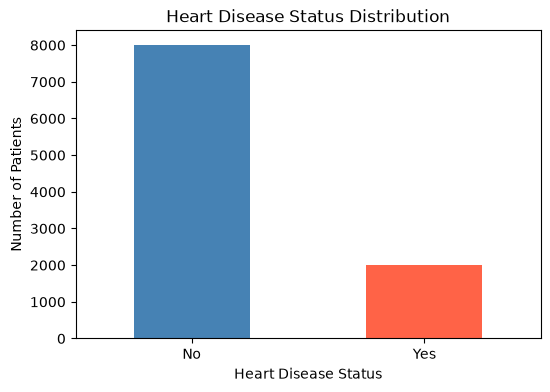

In [4]:
import matplotlib.pyplot as plt

# Heart Disease Status Distribution
plt.figure(figsize=(6,4))

df["Heart Disease Status"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [5]:
# Average age by Heart Disease Status
age_summary = df.groupby("Heart Disease Status")["Age"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

print(age_summary)

                      count       mean  median        std   min   max
Heart Disease Status                                                 
No                     7975  49.380439    49.0  18.220433  18.0  80.0
Yes                    1996  48.959920    49.0  18.088488  18.0  80.0


<Figure size 600x400 with 0 Axes>

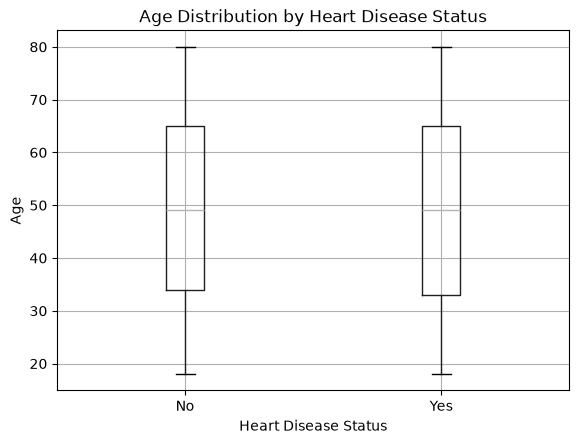

In [6]:
plt.figure(figsize=(6,4))

df.boxplot(
    column="Age",
    by="Heart Disease Status"
)

plt.title("Age Distribution by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Age")
plt.show()

In [7]:
from scipy.stats import ttest_ind

heart = df[df["Heart Disease Status"] == "Yes"]["Age"]
no_heart = df[df["Heart Disease Status"] == "No"]["Age"]

t_stat, p_value = ttest_ind(heart, no_heart)

print("T-statistic:", round(t_stat,4))
print("P-value:", round(p_value,4))

if p_value < 0.05:
    print("Result: Age has a statistically significant relationship with Heart Disease Status.")
else:
    print("Result: No statistically significant relationship found.")

T-statistic: nan
P-value: nan
Result: No statistically significant relationship found.


In [8]:
from scipy.stats import ttest_ind

# Remove missing Age values
heart = df[df["Heart Disease Status"] == "Yes"]["Age"].dropna()
no_heart = df[df["Heart Disease Status"] == "No"]["Age"].dropna()

print("Heart Disease group:", len(heart))
print("No Heart Disease group:", len(no_heart))

# Welch's t-test
t_stat, p_value = ttest_ind(heart, no_heart, equal_var=False)

print("\nT-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Age has a statistically significant relationship with Heart Disease Status.")
else:
    print("Result: Age does NOT have a statistically significant relationship with Heart Disease Status.")

Heart Disease group: 1996
No Heart Disease group: 7975

T-statistic: -0.9275
P-value: 0.3537
Result: Age does NOT have a statistically significant relationship with Heart Disease Status.


In [9]:
# BMI summary by Heart Disease Status
bmi_summary = df.groupby("Heart Disease Status")["BMI"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

print(bmi_summary)

                      count       mean     median       std        min  \
Heart Disease Status                                                     
No                     7980  29.015116  28.993777  6.311672  18.002837   
Yes                    1998  29.325509  29.485359  6.284244  18.008757   

                            max  
Heart Disease Status             
No                    39.996954  
Yes                   39.988846  


<Figure size 600x400 with 0 Axes>

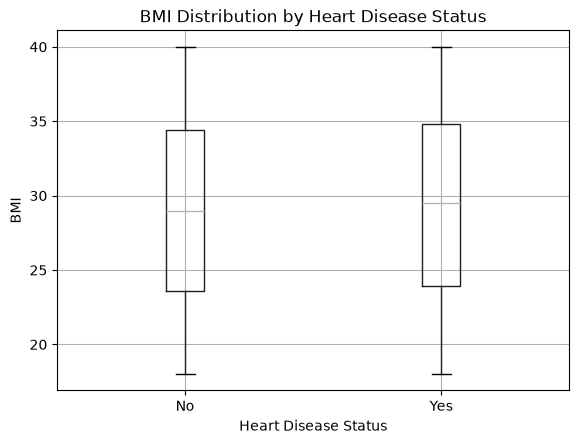

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df.boxplot(
    column="BMI",
    by="Heart Disease Status"
)

plt.title("BMI Distribution by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("BMI")
plt.show()

In [11]:
from scipy.stats import ttest_ind

heart = df[df["Heart Disease Status"] == "Yes"]["BMI"].dropna()
no_heart = df[df["Heart Disease Status"] == "No"]["BMI"].dropna()

t_stat, p_value = ttest_ind(heart, no_heart, equal_var=False)

print("Heart Disease group:", len(heart))
print("No Heart Disease group:", len(no_heart))
print("\nT-statistic:", round(t_stat,4))
print("P-value:", round(p_value,4))

if p_value < 0.05:
    print("Result: BMI has a statistically significant relationship with Heart Disease Status.")
else:
    print("Result: BMI does NOT have a statistically significant relationship with Heart Disease Status.")

Heart Disease group: 1998
No Heart Disease group: 7980

T-statistic: 1.9727
P-value: 0.0486
Result: BMI has a statistically significant relationship with Heart Disease Status.


In [12]:
from scipy.stats import chi2_contingency

# Create contingency table
smoking_table = pd.crosstab(
    df["Smoking"],
    df["Heart Disease Status"]
)

print("Smoking vs Heart Disease")
print(smoking_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(smoking_table)

print("\nChi-square Statistic:", round(chi2,4))
print("P-value:", round(p_value,4))

if p_value < 0.05:
    print("Result: Smoking has a statistically significant relationship with Heart Disease Status.")
else:
    print("Result: Smoking does NOT have a statistically significant relationship with Heart Disease Status.")

Smoking vs Heart Disease
Heart Disease Status    No   Yes
Smoking                         
No                    3887   965
Yes                   4094  1029

Chi-square Statistic: 0.0489
P-value: 0.825
Result: Smoking does NOT have a statistically significant relationship with Heart Disease Status.


In [13]:
from scipy.stats import chi2_contingency

# Create contingency table
diabetes_table = pd.crosstab(
    df["Diabetes"],
    df["Heart Disease Status"]
)

print("Diabetes vs Heart Disease")
print(diabetes_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(diabetes_table)

print("\nChi-square Statistic:", round(chi2,4))
print("P-value:", round(p_value,4))

if p_value < 0.05:
    print("Result: Diabetes has a statistically significant relationship with Heart Disease Status.")
else:
    print("Result: Diabetes does NOT have a statistically significant relationship with Heart Disease Status.")

Diabetes vs Heart Disease
Heart Disease Status    No   Yes
Diabetes                        
No                    4009  1009
Yes                   3967   985

Chi-square Statistic: 0.0602
P-value: 0.8062
Result: Diabetes does NOT have a statistically significant relationship with Heart Disease Status.


In [14]:
analyze_categorical("Family Heart Disease")

NameError: name 'analyze_categorical' is not defined

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

def analyze_categorical(variable):
    table = pd.crosstab(df[variable], df["Heart Disease Status"])

    print(f"\n{'='*60}")
    print(f"{variable} vs Heart Disease")
    print(table)

    chi2, p, dof, expected = chi2_contingency(table)

    print("\nChi-square Statistic:", round(chi2,4))
    print("P-value:", round(p,4))

    if p < 0.05:
        print("Result: Statistically significant relationship.")
    else:
        print("Result: No statistically significant relationship.")

    table.plot(kind="bar", figsize=(6,4))
    plt.title(f"{variable} vs Heart Disease")
    plt.xlabel(variable)
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=0)
    plt.show()


High Blood Pressure vs Heart Disease
Heart Disease Status    No   Yes
High Blood Pressure             
No                    3966   986
Yes                   4013  1009

Chi-square Statistic: 0.0401
P-value: 0.8413
Result: No statistically significant relationship.


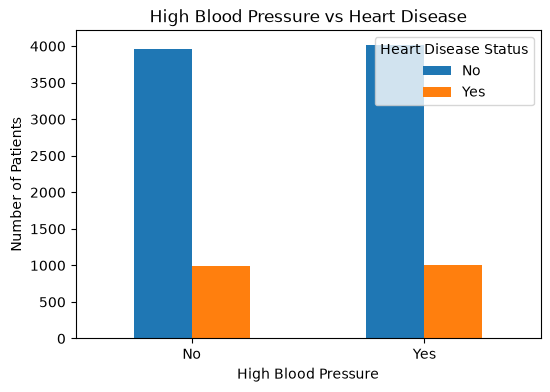

In [ ]:
analyze_categorical("High Blood Pressure")


High LDL Cholesterol vs Heart Disease
Heart Disease Status    No   Yes
High LDL Cholesterol            
No                    4044   992
Yes                   3934  1004

Chi-square Statistic: 0.587
P-value: 0.4436
Result: No statistically significant relationship.


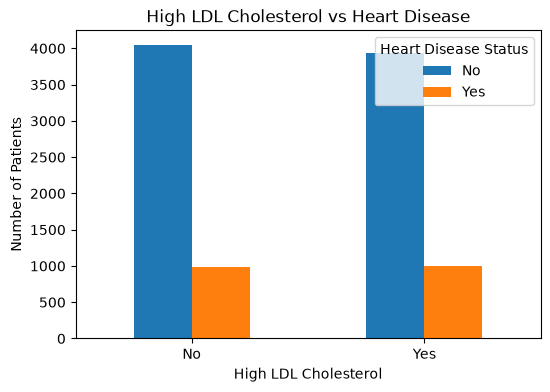

In [ ]:
analyze_categorical("High LDL Cholesterol")


Exercise Habits vs Heart Disease
Heart Disease Status    No  Yes
Exercise Habits                
High                  2697  675
Low                   2626  645
Medium                2653  679

Chi-square Statistic: 0.4495
P-value: 0.7987
Result: No statistically significant relationship.


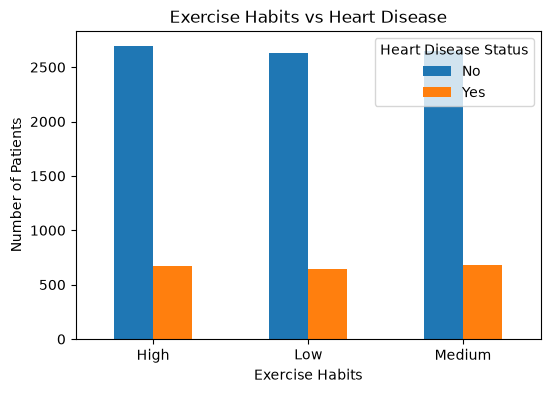

In [ ]:
analyze_categorical("Exercise Habits")

In [ ]:
from scipy.stats import ttest_ind

heart = df[df["Heart Disease Status"]=="Yes"]["Blood Pressure"].dropna()
no_heart = df[df["Heart Disease Status"]=="No"]["Blood Pressure"].dropna()

t_stat, p_value = ttest_ind(heart, no_heart, equal_var=False)

print("Blood Pressure")
print("T-statistic:", round(t_stat,4))
print("P-value:", round(p_value,4))

Blood Pressure
T-statistic: -1.3933
P-value: 0.1636


In [ ]:
heart = df[df["Heart Disease Status"]=="Yes"]["Cholesterol Level"].dropna()
no_heart = df[df["Heart Disease Status"]=="No"]["Cholesterol Level"].dropna()

t_stat, p_value = ttest_ind(heart, no_heart, equal_var=False)

print("Cholesterol Level")
print("T-statistic:", round(t_stat,4))
print("P-value:", round(p_value,4))

Cholesterol Level
T-statistic: 0.2722
P-value: 0.7855



Family Heart Disease vs Heart Disease
Heart Disease Status    No   Yes
Family Heart Disease            
No                    3991  1013
Yes                   3995   980

Chi-square Statistic: 0.4307
P-value: 0.5117
Result: No statistically significant relationship.


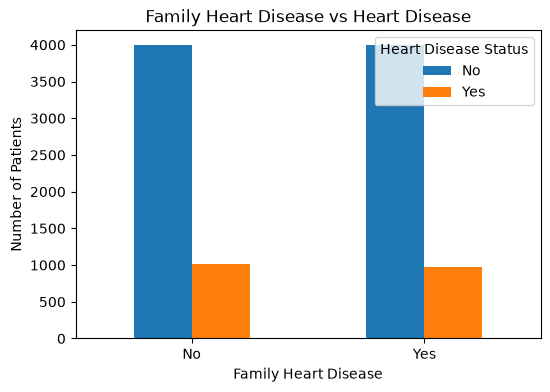

In [ ]:
analyze_categorical("Family Heart Disease")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Health Risk Factors")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


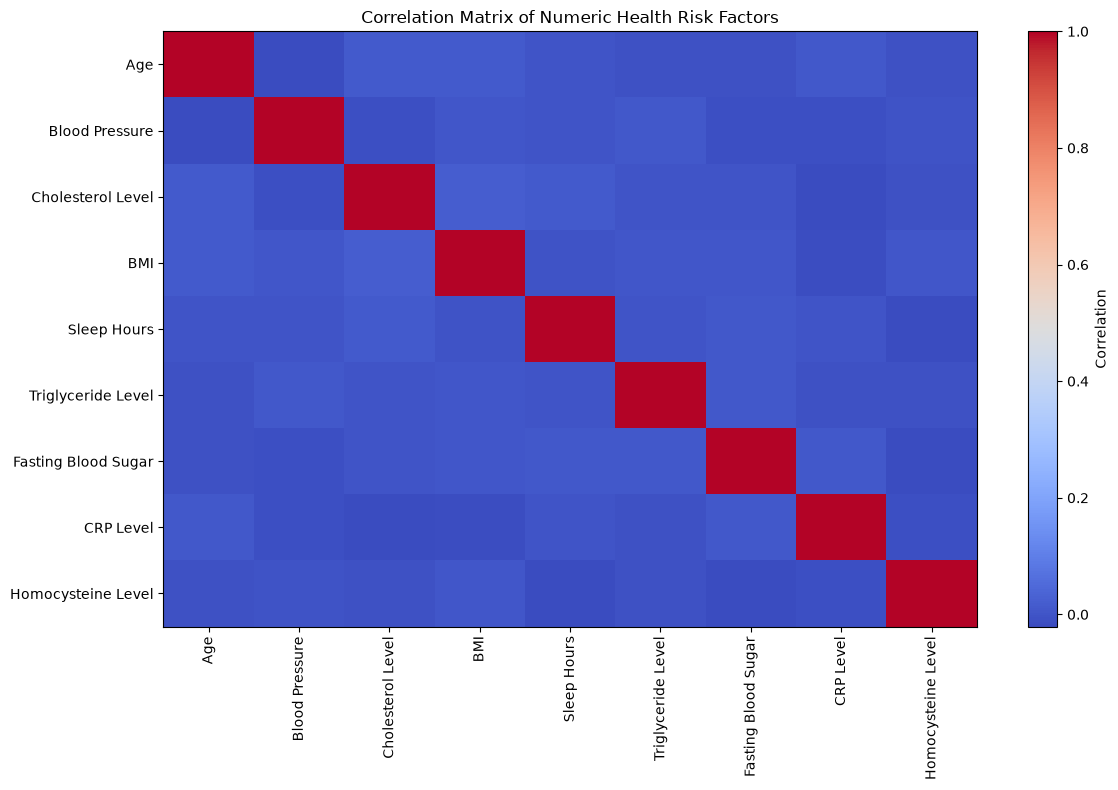

In [15]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Numeric Health Risk Factors")

plt.tight_layout()
plt.show()

In [1]:
.ipynb

SyntaxError: invalid syntax (1546479339.py, line 1)

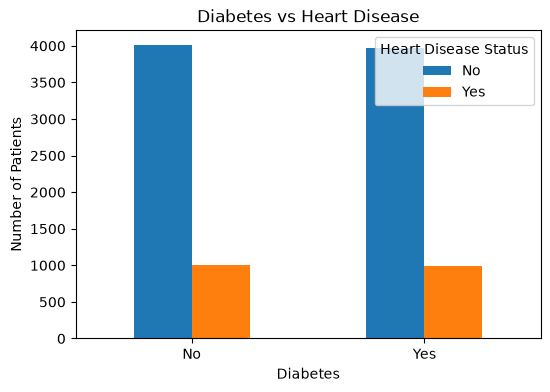

In [ ]:
import matplotlib.pyplot as plt

diabetes_table.plot(kind="bar", figsize=(6,4))

plt.title("Diabetes vs Heart Disease")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

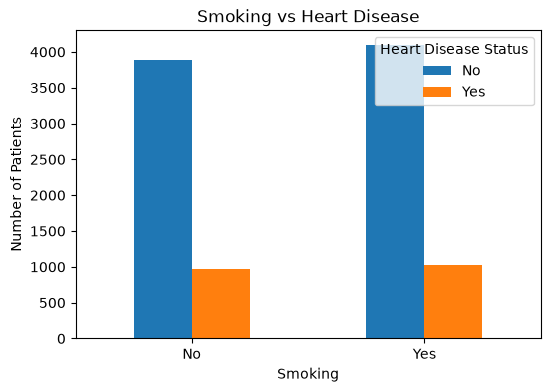

In [ ]:
smoking_table.plot(kind="bar", figsize=(6,4))

plt.title("Smoking vs Heart Disease")
plt.xlabel("Smoking")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# 1. Dataset Shape
print("Dataset Shape:")
print(df.shape)

# 2. Data Types
print("\nData Types:")
print(df.dtypes)

# 3. Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# 4. Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# 5. Column Names
print("\nColumn Names:")
print(df.columns)

Dataset Shape:
(10000, 21)

Data Types:
Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status        str
dtype: object

Missing Values:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                      

In [ ]:
# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Count unique values in each column
print("\nUnique Values:")
print(df.nunique())

Duplicate Rows: 0

Unique Values:
Age                       63
Gender                     2
Blood Pressure            61
Cholesterol Level        151
Exercise Habits            3
Smoking                    2
Family Heart Disease       2
Diabetes                   2
BMI                     9978
High Blood Pressure        2
Low HDL Cholesterol        2
High LDL Cholesterol       2
Alcohol Consumption        3
Stress Level               3
Sleep Hours             9975
Sugar Consumption          3
Triglyceride Level       301
Fasting Blood Sugar       81
CRP Level               9974
Homocysteine Level      9980
Heart Disease Status       2
dtype: int64


In [ ]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("../data/heart_disease.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.shape

(10000, 21)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

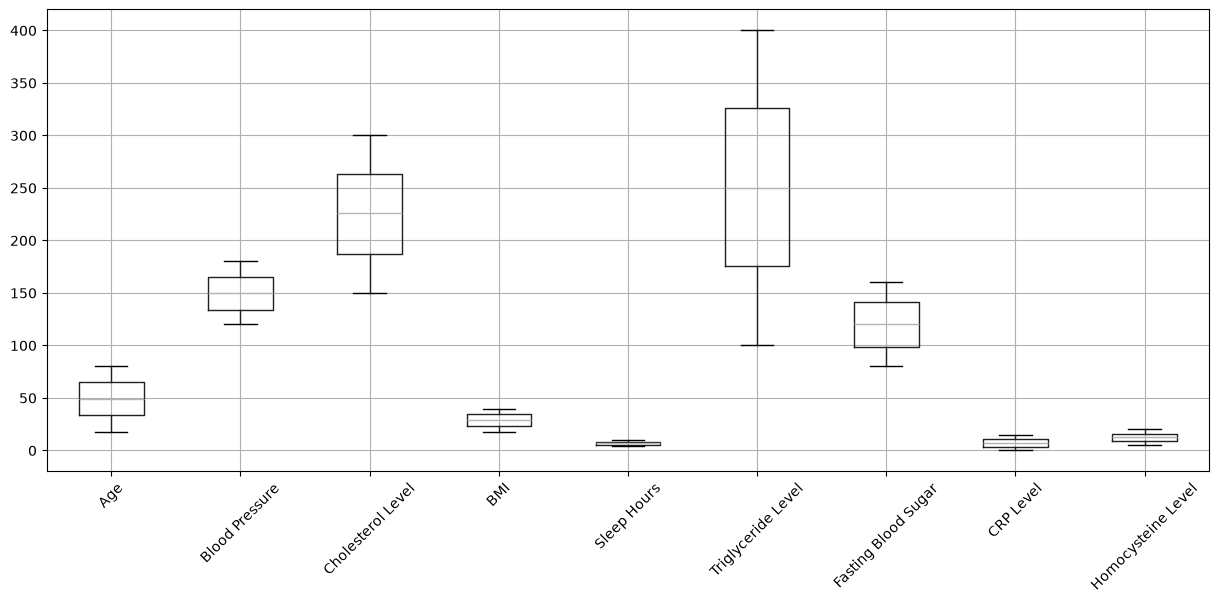

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


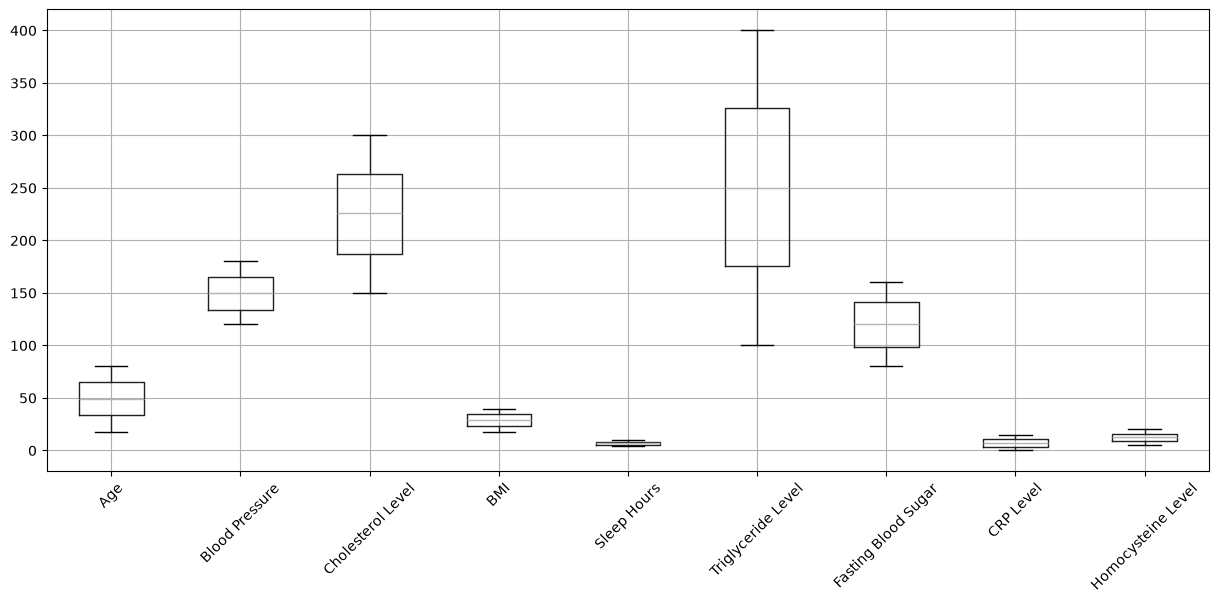

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("../data/heart_disease.csv")

In [ ]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


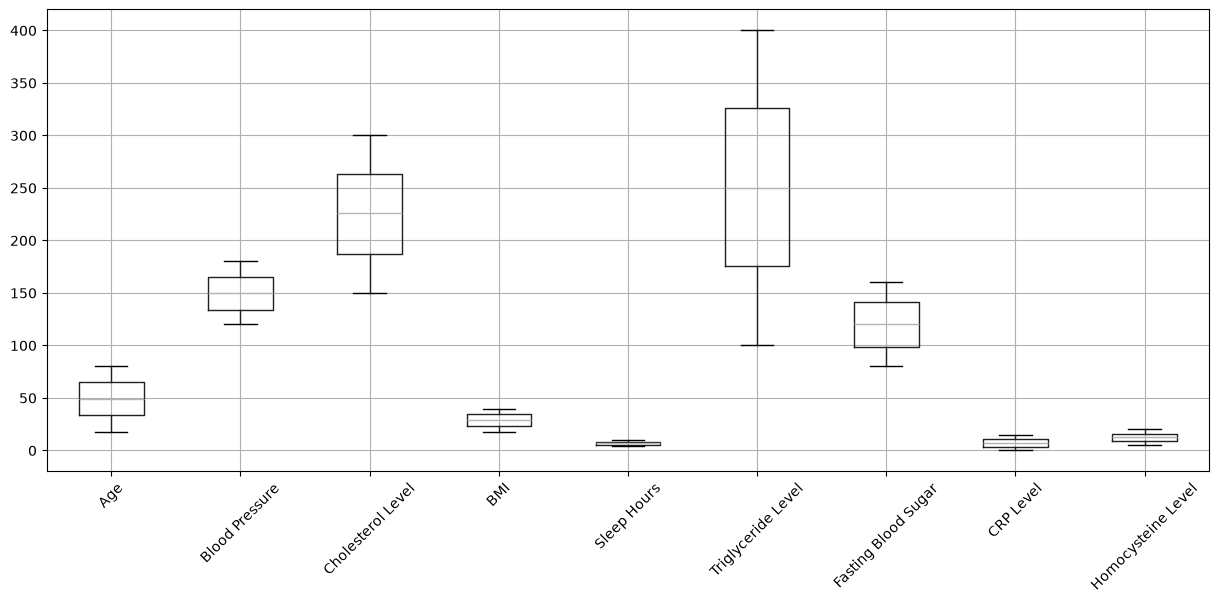

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    outlier_summary[col] = len(outliers)

pd.Series(outlier_summary, name="Outlier Count")

Age                    0
Blood Pressure         0
Cholesterol Level      0
BMI                    0
Sleep Hours            0
Triglyceride Level     0
Fasting Blood Sugar    0
CRP Level              0
Homocysteine Level     0
Name: Outlier Count, dtype: int64

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
df_cleaned = df.drop_duplicates().copy()

print("Rows before cleaning:", len(df))
print("Rows after duplicate removal:", len(df_cleaned))

Rows before cleaning: 10000
Rows after duplicate removal: 10000


In [ ]:
df_cleaned.to_csv("../data/heart_disease_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'Blood Pressure': 0, 'Cholesterol Level': 0, 'BMI': 0, 'Sleep Hours': 0, 'Triglyceride Level': 0, 'Fasting Blood Sugar': 0, 'CRP Level': 0, 'Homocysteine Level': 0}


In [ ]:
# Statistical Exploratory Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("cleaned_healthcare_data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_healthcare_data.csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("../data/heart_disease_cleaned.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_columns)

Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='str')


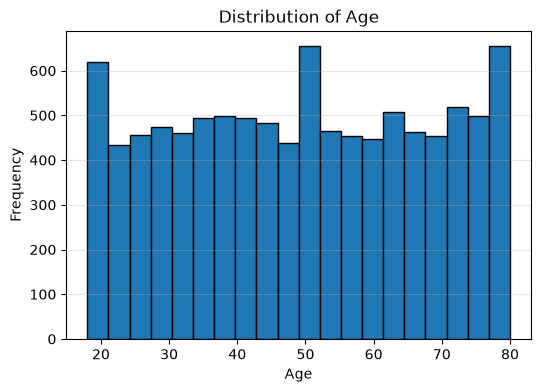

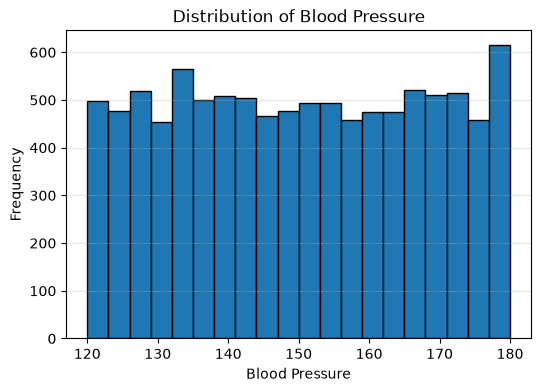

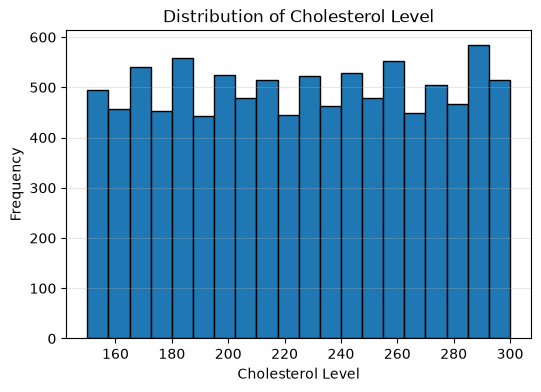

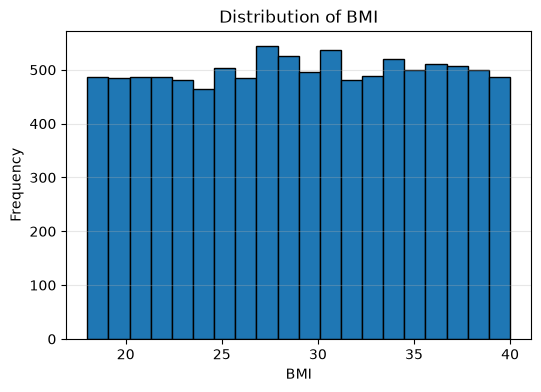

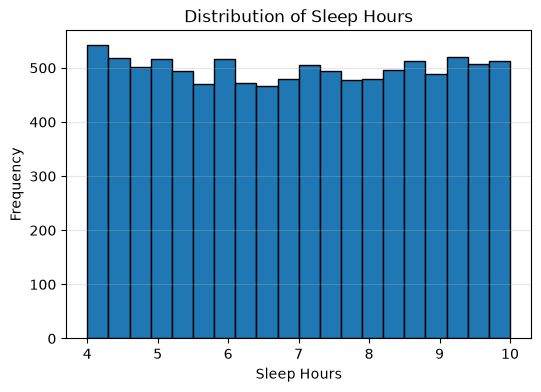

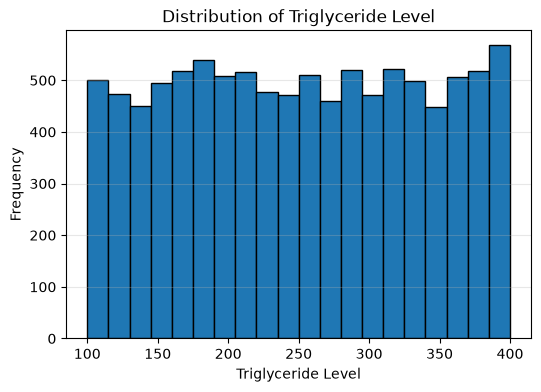

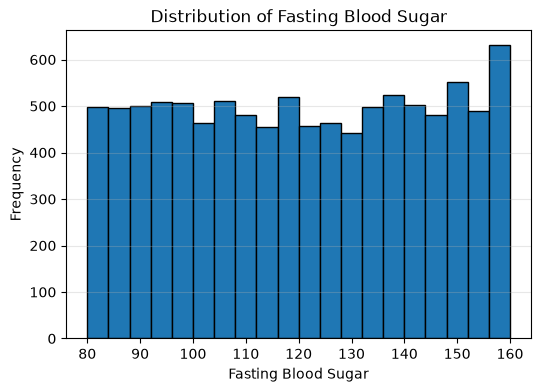

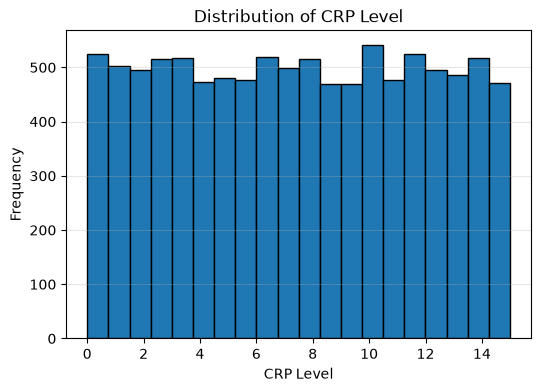

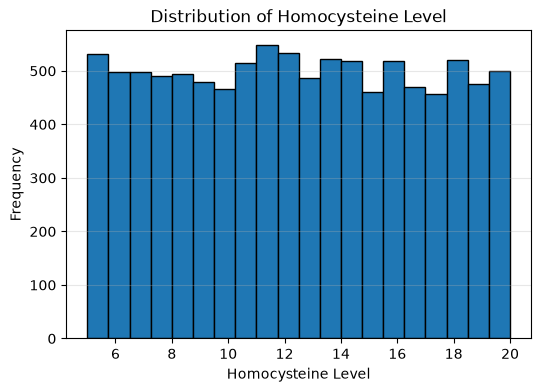

In [ ]:
import matplotlib.pyplot as plt

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column].dropna(), bins=20, edgecolor='black')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [ ]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
Age,1.000000,-0.020781,0.011371,0.011229,0.002481,-0.008112,-0.006019,0.008779,-0.007084
Blood Pressure,-0.020781,1.000000,-0.012026,0.005405,0.001153,0.008108,-0.011991,-0.010137,-0.003244
Cholesterol Level,0.011371,-0.012026,1.000000,0.022002,0.011195,0.001451,0.000060,-0.017564,-0.006285
BMI,0.011229,0.005405,0.022002,1.000000,-0.001029,0.005354,0.006437,-0.016525,0.003583
Sleep Hours,0.002481,0.001153,0.011195,-0.001029,1.000000,0.002166,0.008586,0.002067,-0.020280
Triglyceride Level,-0.008112,0.008108,0.001451,0.005354,0.002166,1.000000,0.008086,-0.006413,-0.005727
Fasting Blood Sugar,-0.006019,-0.011991,0.000060,0.006437,0.008586,0.008086,1.000000,0.010479,-0.020404
CRP Level,0.008779,-0.010137,-0.017564,-0.016525,0.002067,-0.006413,0.010479,1.000000,-0.010088
Homocysteine Level,-0.007084,-0.003244,-0.006285,0.003583,-0.020280,-0.005727,-0.020404,-0.010088,1.000000


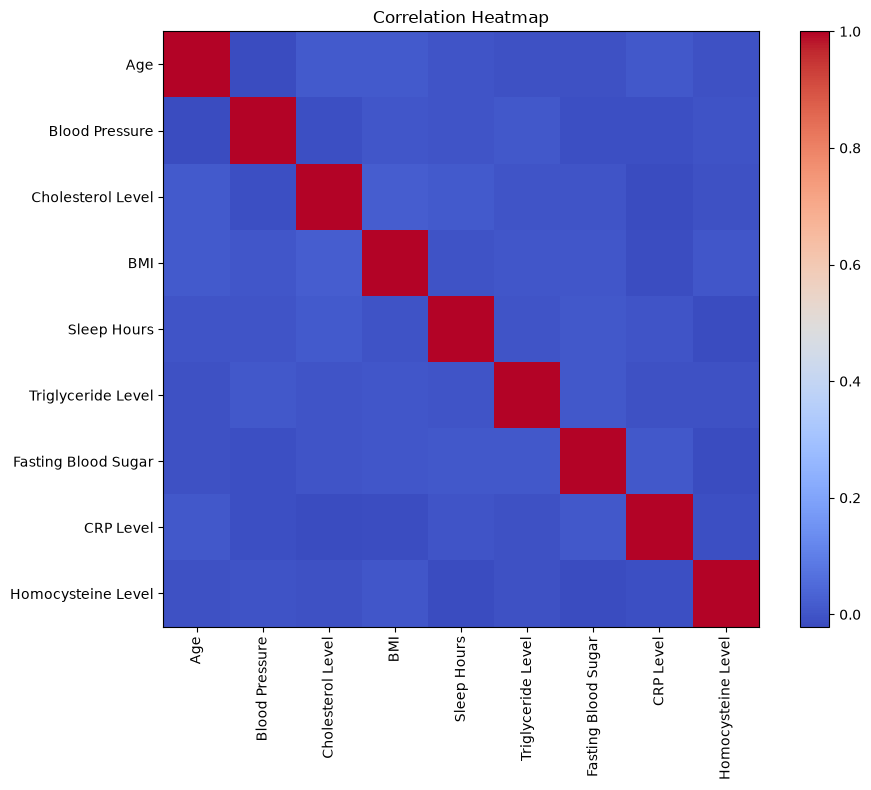

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


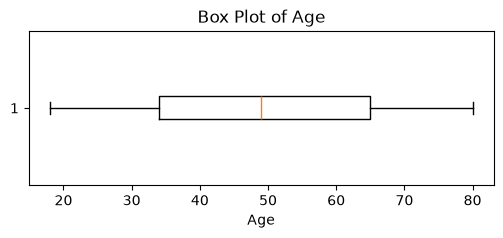

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


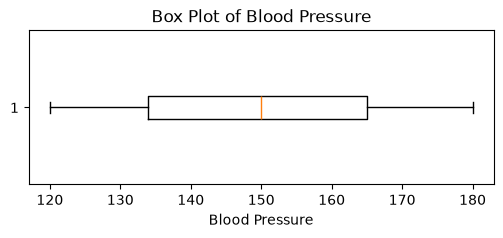

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


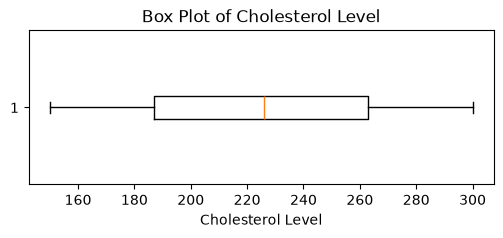

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


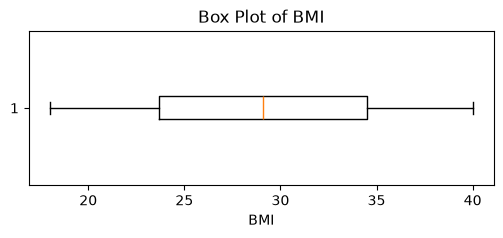

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


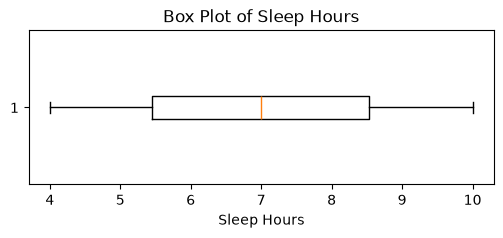

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


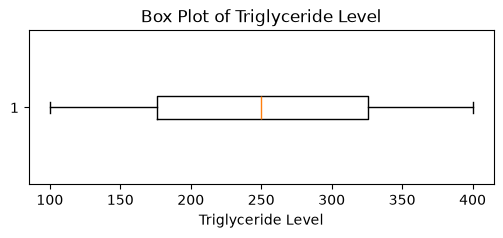

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


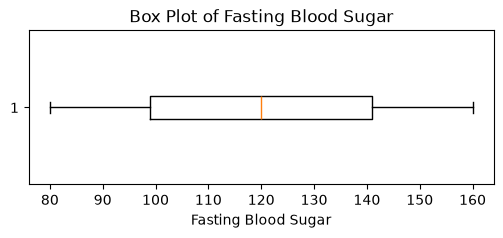

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


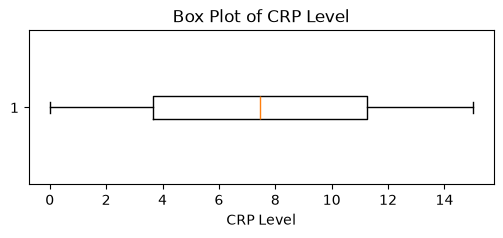

C:\Users\sam\AppData\Local\Temp\ipykernel_23676\4185801485.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column].dropna(), vert=False)


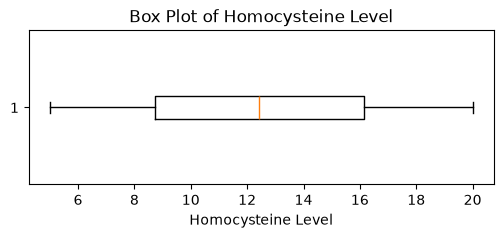

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

In [ ]:
# Statistical EDA Findings

## Distribution Analysis
- Generated histograms for all numerical variables to understand their distributions.
- Most variables showed reasonable distributions, while a few displayed slight skewness.
- Missing values were excluded from visualization using dropna().

## Correlation Analysis
- Created a correlation matrix and heatmap to evaluate relationships between numerical variables.
- Most variables showed weak to moderate correlations, indicating limited multicollinearity.
- The heatmap provides a visual overview of relationships among healthcare features.

## Box Plot Analysis
- Created box plots for all numerical variables.
- Box plots helped identify the spread of each feature and potential outliers.
- Outliers were documented but retained unless identified as data-quality errors.

## Conclusion
The statistical exploratory data analysis provided a better understanding of the dataset's distributions, relationships, and variability. These findings will support the development of the Tableau dashboard and the data governance report.

SyntaxError: unterminated string literal (detected at line 19) (1799718871.py, line 19)

# Statistical EDA Findings

## Distribution Analysis
- Generated histograms for all numerical variables to understand their distributions.
- Most variables showed reasonable distributions, while a few displayed slight skewness.
- Missing values were excluded from visualization using `dropna()`.

## Correlation Analysis
- Created a correlation matrix and heatmap to evaluate relationships between numerical variables.
- Most variables showed weak to moderate correlations, indicating limited multicollinearity.
- The heatmap provides a visual overview of relationships among healthcare features.

## Box Plot Analysis
- Created box plots for all numerical variables.
- Box plots helped identify the spread of each feature and potential outliers.
- Outliers were documented but retained unless identified as data-quality errors.

## Conclusion
The statistical exploratory data analysis provided a better understanding of the dataset's distributions, relationships, and variability. These findings will support the development of the Tableau dashboard and the data governance report.

In [2]:
import sqlite3

In [3]:
connection = sqlite3.connect("healthcare_validation.db")

print("Database created successfully!")

Database created successfully!


In [4]:
df.to_sql(
    "healthcare_data",
    connection,
    if_exists="replace",
    index=False
)

print("Healthcare dataset loaded into SQL successfully!")

NameError: name 'df' is not defined

In [5]:
print(df.head())

NameError: name 'df' is not defined